In [161]:
PRICE_COOF = 10000000 

import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from matplotlib import pyplot as plt

In [162]:
def onehot_encoding(x: np.ndarray):
    L = len(x)
    x1 = np.sort(x)
    w = {}
    N = 0
    for j in x1:
        if j not in w:
            w[j] = N
            N += 1

    f = np.eye(N, N, dtype = np.float32)
    Q = np.empty([L, N], np.float32)
    for j, i in enumerate(x):
        Q[j] = f[w[i]]

    return Q


def minmax_scale(X: np.ndarray):
    if len(X) <= 1:
        return np.zeros_like(X, np.float32)
    Mi = X.min(axis=0)
    Ma = X.max(axis=0)
    return (X - Mi) / (Ma - Mi)

In [163]:
Xdf = pd.read_csv('X_train.csv')
Ydf = pd.read_csv('y_train.csv')

In [164]:
Xdf = Xdf.drop(columns='Unnamed: 0')
Ydf = Ydf.drop(columns='Unnamed: 0')

In [165]:
Xdf

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Address
0,71043.313249,6.046182,6.095862,3.34,20763.604137,"80638 Samantha Village\nNorth Anthony, KS 5865..."
1,65632.925982,6.420381,5.929531,4.43,42803.221409,76258 Miller Station Suite 386\nLake Heatherpo...
2,74960.767664,6.467532,6.483896,3.27,35918.893782,"7925 Rebecca Cliff Apt. 790\nEast Amanda, OH 8..."
3,71309.250170,7.513611,8.409303,4.35,32356.997377,"701 Michael Courts\nLake Diamondchester, ND 59..."
4,68898.345913,6.787649,7.871353,6.39,39515.571562,"777 Ross Crossroad\nKaiserville, RI 24445"
...,...,...,...,...,...,...
3495,67136.075499,6.218487,8.408889,5.17,31846.253359,USNV Stewart\nFPO AE 91835
3496,48144.053206,5.440212,8.419112,4.48,23465.382981,"674 Karen Pine Apt. 327\nEdwardsfurt, MS 08007..."
3497,78951.735897,5.443039,5.759583,2.18,31055.051090,"PSC 1520, Box 7020\nAPO AE 71780-5009"
3498,80040.173315,6.449555,8.453262,5.50,29699.011639,"8337 Cody Fields Apt. 592\nTinafurt, GU 56684-..."


In [166]:
Ydf

,Price
0,9.551656e+05
1,1.184527e+06
2,1.268135e+06
3,1.752968e+06
4,1.530124e+06
...,...
3495,1.468753e+06
3496,7.638741e+05
3497,1.241183e+06
3498,1.735826e+06


In [167]:
Xdf['Price'] = Ydf['Price']

In [168]:
Xdf['Price'] /= PRICE_COOF
df = Xdf

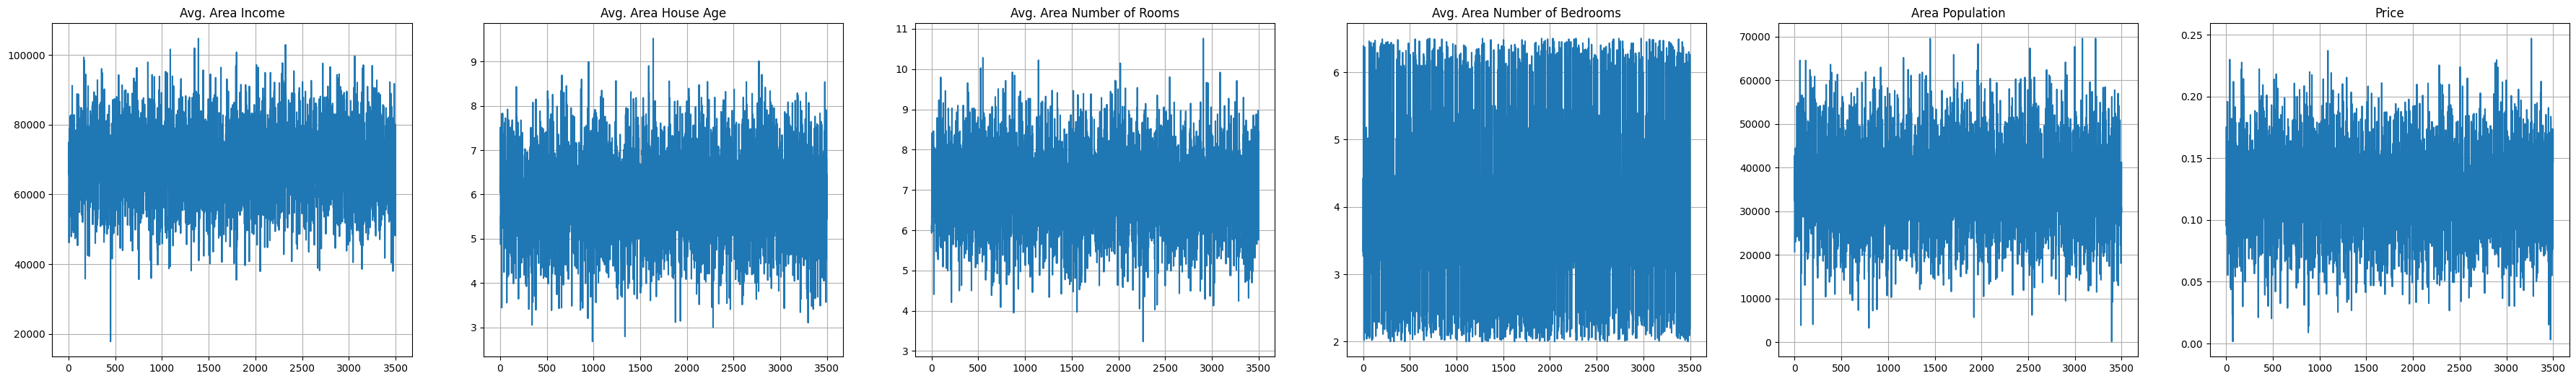

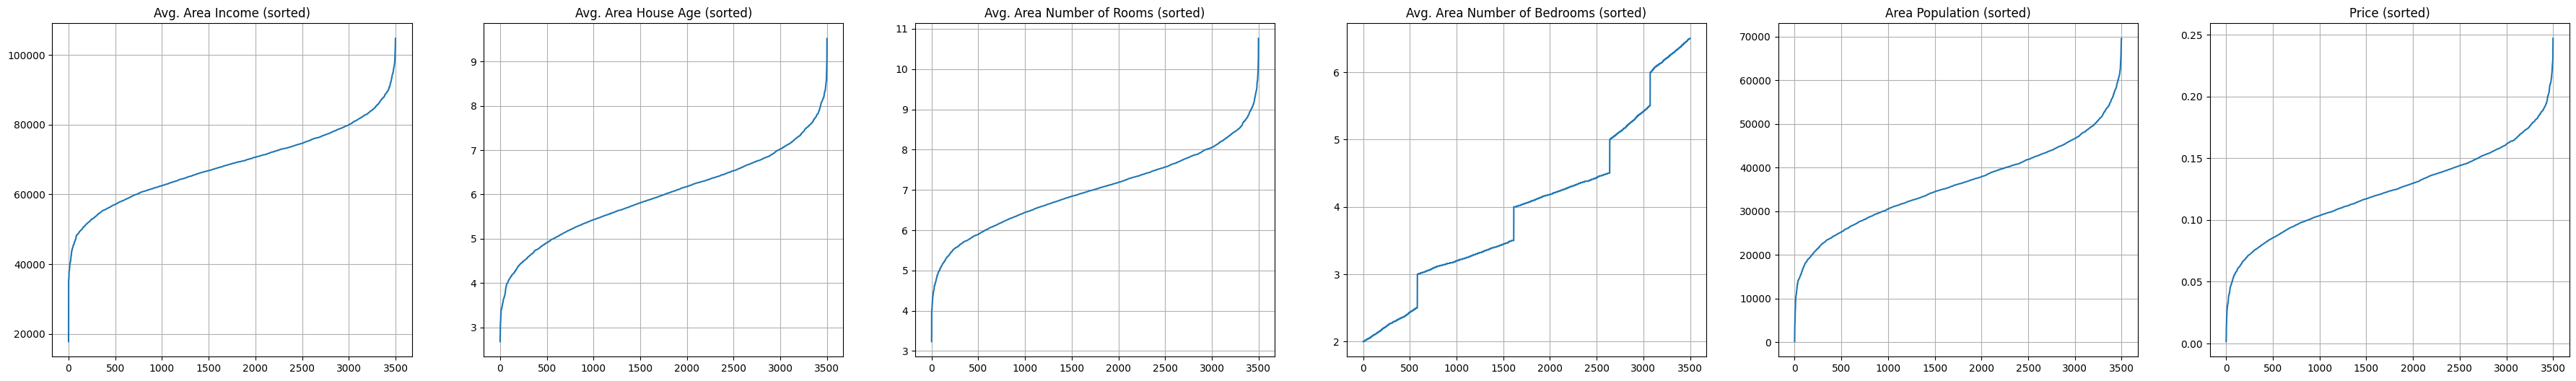

In [169]:
def show_all_count(key = None):
    q = list(df.dtypes[df.dtypes != "object"].keys())
    c = not (key is None)
    fig, ax = plt.subplots(1, len(q), figsize=(45, 6))
    for n, i in enumerate(q):
        ax[n].plot(key(df[i]) if c else df[i])
        ax[n].set_title(i + (f" ({key.__name__})" if c else ''))
        ax[n].grid(True)
    plt.show()

show_all_count()
show_all_count(sorted) # так же выведем в отсортированном порядке, что бы наглядно увидеть долю выбросов

500 - 3000


In [170]:
df = df[(df['Avg. Area Income'] < 85000) & (df['Avg. Area Income'] > 60000)]
df = df[(df['Avg. Area House Age'] > 5) & (df['Avg. Area House Age'] < 7)]
df = df[(df['Area Population'] > 25000) & (df['Area Population'] < 50000)]
df = df[(df['Price'] > 0.10) & (df['Price'] < 0.17)]

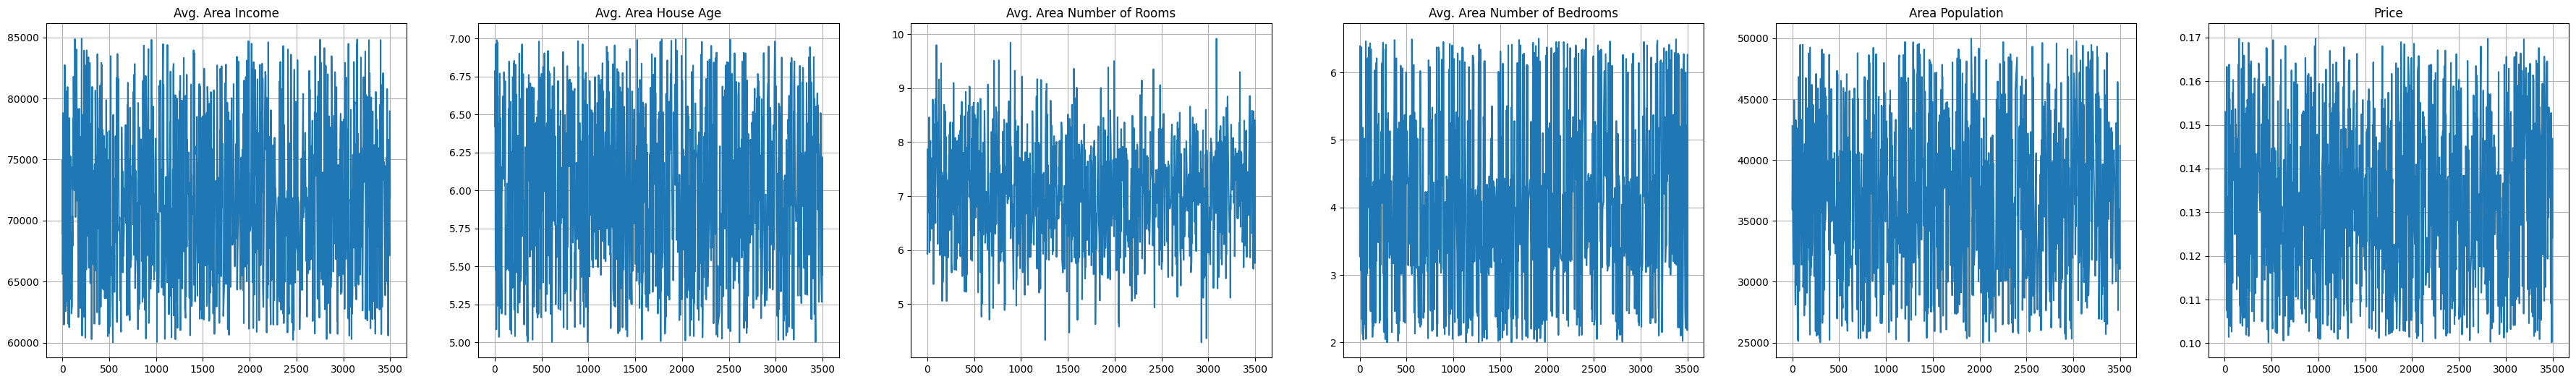

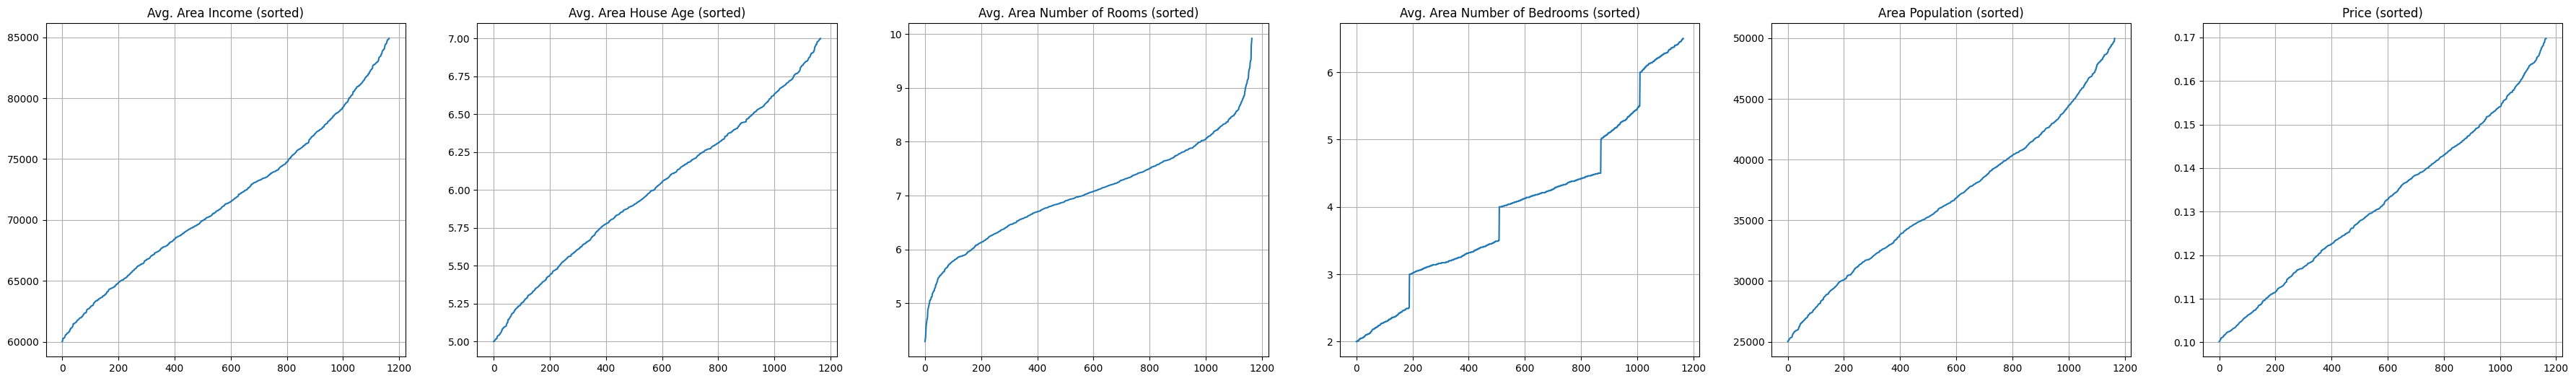

In [171]:
show_all_count()
show_all_count(sorted) # так же выведем в отсортированном порядке, что бы наглядно увидеть долю выбросов

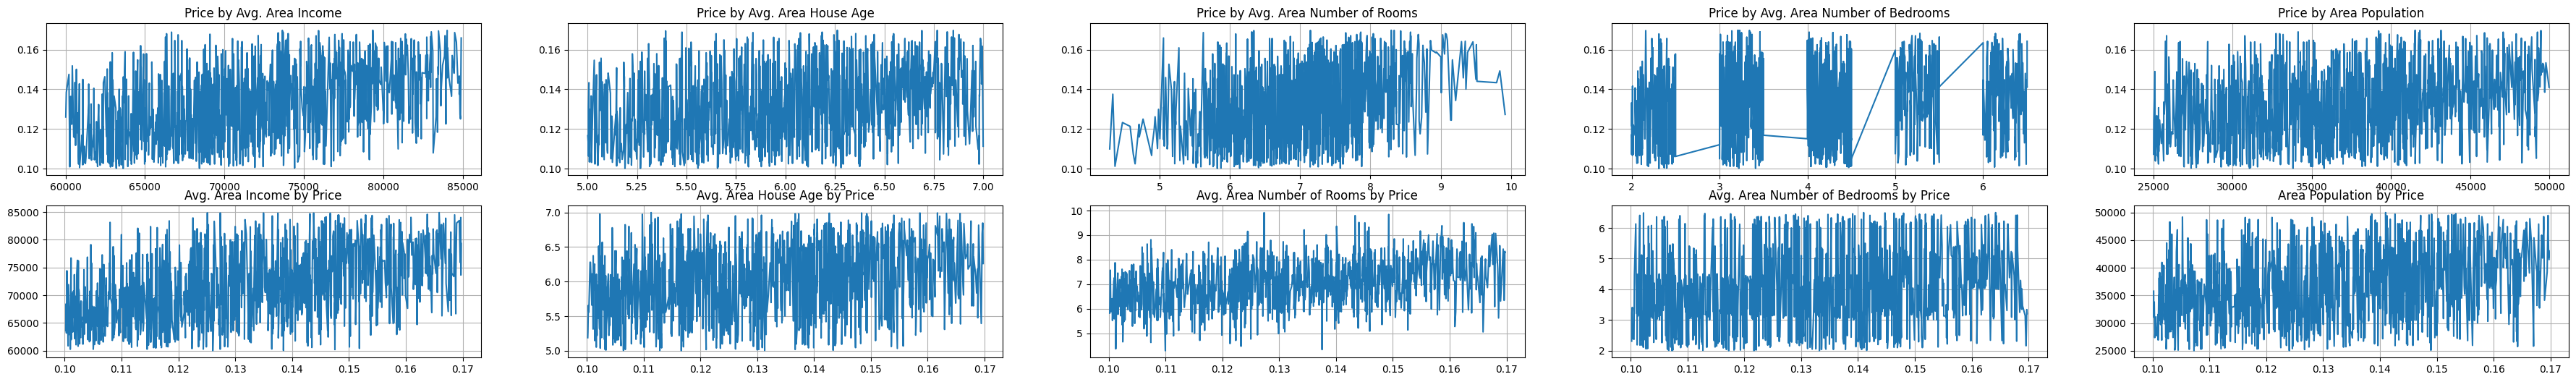

In [172]:
def get_value_dependentes(name, value = 'Price'):
    G = df.sort_values(by = [name])
    return [G[name], G[value]]

def show_all_value_depends(value = 'Price'):
    q = list(df.dtypes[df.dtypes != "object"].keys())
    q.remove(value)
    fig, ax = plt.subplots(2, len(q), figsize=(45, 6))
    for n, i in enumerate(q):
        ax[0][n].plot(*get_value_dependentes(i, value))
        ax[0][n].set_title(f'{value} by {i}')
        ax[0][n].grid(True)
    for n, i in enumerate(q):
        ax[1][n].plot(*get_value_dependentes(value, i))
        ax[1][n].set_title(f'{i} by {value}')
        ax[1][n].grid(True)
    plt.show()

show_all_value_depends()

In [173]:
def get_price_info(value_name, print_info = True): # показывает долю страховых выплат по каждому значению категориального параметра
    global df
    VU = df[value_name].unique()
    HH = {}
    for v in VU:
        Q = df[(df[value_name] == v)]['Price']
        s = Q.sum()/len(Q)
        if print_info:print(f"{v} : {100*s}%")
        HH[v] = s

    return HH

def show_all(print_info = True):
    q = list(df.dtypes[df.dtypes == "object"].keys())
    for g in q:
        print(f"============ {g} ==================")
        HH = get_price_info(g)
        plt.pie(HH.values(), labels = HH.keys())
        plt.show()

In [174]:
df = df.drop(columns='Address')

In [175]:
df['Avg. Area Number of Bedrooms'] = df['Avg. Area Number of Bedrooms'].round()
level_map = {2.0:'A', 3.0:'B', 4.0:'C', 5.0:'D', 6.0:'F'}

df['Avg. Area Number of Bedrooms'] = df['Avg. Area Number of Bedrooms'].map(level_map)
df

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
1,65632.925982,6.420381,5.929531,C,42803.221409,0.118453
2,74960.767664,6.467532,6.483896,B,35918.893782,0.126813
4,68898.345913,6.787649,7.871353,F,39515.571562,0.153012
8,78803.122893,5.524755,7.297613,D,34422.030055,0.151732
11,68162.683926,6.962207,6.697358,B,31843.876337,0.121338
...,...,...,...,...,...,...
3484,76611.889322,5.447756,8.570526,D,33001.914666,0.152744
3491,68428.394275,5.266863,6.140597,B,31074.124918,0.100219
3495,67136.075499,6.218487,8.408889,D,31846.253359,0.146875
3497,78951.735897,5.443039,5.759583,A,31055.051090,0.124118


============ Avg. Area Number of Bedrooms ==================
C : 13.046163587489326%
B : 13.254003415007448%
F : 13.707180130029977%
D : 13.797881571557582%
A : 12.694424824286877%


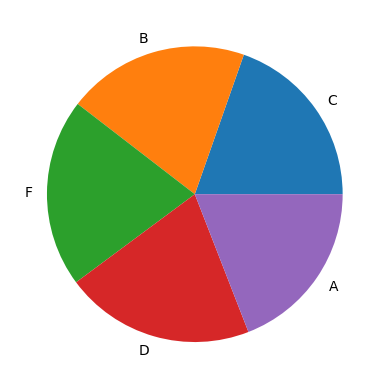

In [176]:
show_all()

In [177]:
def X_operations(X, Y= None, cut = True):
    X = X.drop(columns='Unnamed: 0')
    X = X.drop(columns='Address')
    if cut:
        if not (Y is None):
            X['Price'] = Y['Price']/PRICE_COOF
            X = X[(X['Price'] > 0.10) & (X['Price'] < 0.17)]
        X = X[(X['Avg. Area Income'] < 100000) & (X['Avg. Area Income'] > 60000)]
        X = X[(X['Avg. Area House Age'] > 5) & (X['Avg. Area House Age'] < 7)]
        X = X[(X['Area Population'] > 25000) & (X['Area Population'] < 50000)]

    if not (Y is None) and cut:
        Y = X['Price']
        X = X.drop(columns = 'Price')
    
    X['Avg. Area Number of Bedrooms'] = X['Avg. Area Number of Bedrooms'].round()
    level_map = {2.0:'A', 3.0:'B', 4.0:'C', 5.0:'D', 6.0:'F'}
    X['Avg. Area Number of Bedrooms'] = X['Avg. Area Number of Bedrooms'].map(level_map)
    X = X.drop(columns = 'Avg. Area Number of Bedrooms')
    cat_features_mask = (X.dtypes == "object").values
    X = X.to_numpy()
    X1 = []
    for n, i in enumerate(cat_features_mask):
        if i:
            X1.append(onehot_encoding(X[:, n]).transpose())
        else:
            X1.append(minmax_scale(X[:, n]))


    X = np.vstack(X1).transpose()
    X = np.matrix(X, dtype=np.float64)
    if Y is None:
        return X
    else:
        return Y.to_numpy(), X


In [178]:
Xdf = pd.read_csv('X_train.csv')
y, X = X_operations(Xdf, pd.read_csv('y_train.csv'))

In [179]:
from sklearn.metrics import mean_squared_error
lr = LinearRegression()
lr.fit(np.array(X), np.array(y))
mean_squared_error(y, lr.predict(np.array(X)))

9.39924017246183e-05

In [180]:
Xdf = pd.read_csv('X_test.csv')
X = X_operations(Xdf, cut = False)
predicted = lr.predict(np.array(X))*PRICE_COOF

df = pd.DataFrame({'Predicted':predicted.tolist()})
df.to_csv('./predicted.csv')